In [1]:
# data preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error
from main_source import restructure_data ,model, split_data # import function from other module

D:\jubelio_test\.jubelio_test\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
daily_orders = pd.read_csv('daily_orders_2024_2025.csv')
df = restructure_data(daily_orders)
df

,ds,y
0,2024-01-01,45358
1,2024-01-02,30317
2,2024-01-03,27810
3,2024-01-04,26817
4,2024-01-05,26408
...,...,...
726,2025-12-27,46511
727,2025-12-28,45722
728,2025-12-29,53971
729,2025-12-30,55066


In [3]:
model = model()

In [4]:
# split dataset for your backtesting scheme
df_train = split_data(model,df,0.2)[0]
df_val = split_data(model,df,0.2)[1]

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:940: FutureWarning: DataFrameGroupBy

In [5]:
metrics = model.fit(df_train, validation_df=df_val, progress=None)
metrics

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,49355.140625,57874.886719,0.758594,0.0,0,0.661957,0.0,55162.902344,67470.132812,0.651613,0.0
1,30267.896484,38250.367188,0.418746,0.0,1,0.416382,0.0,37629.199219,45381.195312,0.408680,0.0
2,22111.332031,29527.363281,0.278652,0.0,2,0.219790,0.0,22935.876953,28302.025391,0.216173,0.0
3,10675.728516,19003.275391,0.108717,0.0,3,0.093895,0.0,12754.418945,17287.082031,0.094875,0.0
4,12548.732422,20858.279297,0.128196,0.0,4,0.057969,0.0,9580.546875,13731.463867,0.063006,0.0
...,...,...,...,...,...,...,...,...,...,...,...
995,11505.349609,19971.648438,0.116621,0.0,995,0.038414,0.0,6885.230469,11132.487305,0.038154,0.0
996,11531.887695,20019.615234,0.117170,0.0,996,0.038547,0.0,6639.739746,10741.278320,0.037406,0.0
997,11447.643555,19896.148438,0.115726,0.0,997,0.038485,0.0,6877.056641,11034.589844,0.040695,0.0
998,11422.541992,19874.410156,0.115381,0.0,998,0.038567,0.0,6724.175293,10547.288086,0.037309,0.0


**Forecast total daily order volume across all 10 merchants combined for 2026-01-01 → 2026-06-30**

In [6]:
from datetime import date, timedelta
start_date = date(2026, 1, 1)
# end_date = date.today()
end_date = date(2026, 12, 31)

dates_list = []

current_date = start_date
while current_date <= end_date:
    dates_list.append(current_date)
    current_date += timedelta(days=1)

future = model.make_future_dataframe(
    df, n_historic_predictions=len(dates_list)-1
)

forecast = model.predict(df=future)
forecast['ds'] = dates_list
forecast[:len(dates_list)-1]

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - D:\jubelio_test\.jubelio_test\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warni

,ds,y,yhat1,trend,season_yearly,season_weekly,season_daily,events_additive,event_Hari Buruh Internasional,event_Hari Kemerdekaan Republik Indonesia,...,event_Hari Suci Nyepi,event_Hari kedua dari Hari Raya Idul Fitri,event_Isra Mikraj Nabi Muhammad,event_Kebangkitan Yesus Kristus,event_Kenaikan Yesus Kristus,event_Maulid Nabi Muhammad,event_Tahun Baru Imlek,event_Tahun Baru Islam,event_Tahun Baru Masehi,event_Wafat Yesus Kristus
0,2026-01-01,36014,33639.660156,31148.396484,-1541.522827,349.192108,3683.594238,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-01-02,33171,32894.496094,31157.876953,-1736.677856,-196.897369,3670.192871,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-01-03,30224,31534.839844,31167.361328,-1944.896362,-1394.065918,3706.441895,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-01-04,29314,32749.978516,31176.841797,-2166.404297,168.630157,3570.909912,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-01-05,30418,33933.488281,31186.326172,-2401.315918,1591.288696,3557.188721,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,2026-12-26,46511,36125.015625,34552.511719,-549.831970,-1392.734619,3515.067871,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
360,2026-12-27,45722,37539.855469,34561.992188,-687.744263,165.165070,3500.441895,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
361,2026-12-28,53971,39099.289062,34571.476562,-831.817810,1590.614014,3769.017578,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
362,2026-12-29,55066,36840.093750,34580.957031,-983.433960,-392.115509,3634.685303,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
result = forecast[:186]
# result['ds']

Text(0, 0.5, 'Total Orders')

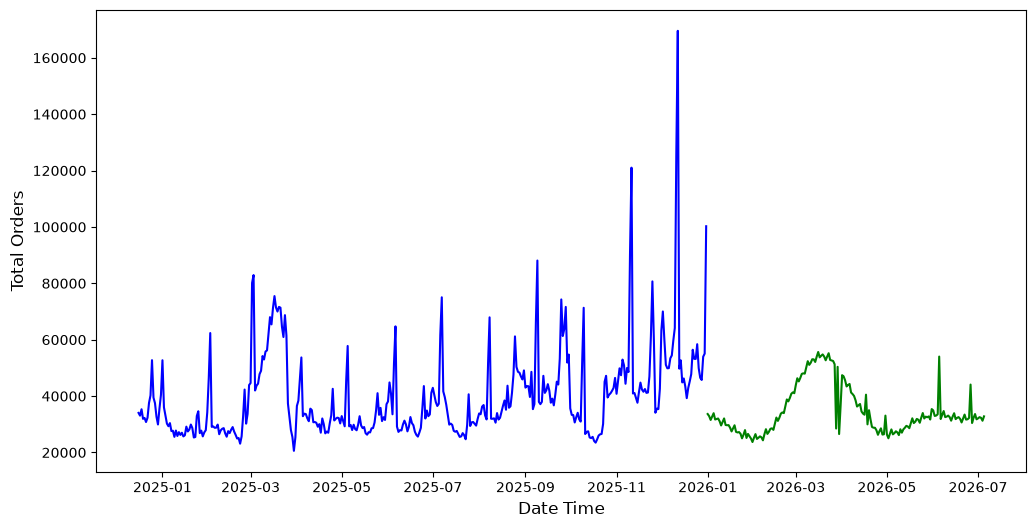

In [8]:
#plotting result
fig, ax1 = plt.subplots(figsize=(12, 6))
x_full = np.array(pd.to_datetime(df['ds']))
y_full = np.array(df['y'])
ds_pred = np.array(pd.to_datetime(result['ds']))
y_pred = np.array(result['yhat1'])
plt.plot(x_full[350:], y_full[350:], color = 'blue', label = 'Dataset')
plt.plot(ds_pred, y_pred, color ='green', label = 'NeuralProphet prediction')
plt.xlabel('Date Time', fontsize = 12)
plt.ylabel('Total Orders',fontsize = 12 )